In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
import requests

# running
## List of world records in athletics (wikipedia)
The main wikipedia page is @ [https://en.wikipedia.org/wiki/List_of_world_records_in_athletics](https://en.wikipedia.org/wiki/List_of_world_records_in_athletics)

### There are diff. categories
ie. outdoor, indoor, etc. For each ther are tables for male and female records

In [2]:
year = "2003"
output_dir = "/tmp/running/" 
my_url = "https://en.wikipedia.org/wiki/" + "List_of_world_records_in_athletics" # sin la barra
print(my_url, output_dir)
#!wikitablescrape --url={my_url}  --output-folder={output_dir}
os.makedirs(output_dir, exist_ok=True)

# Headers para evitar el 403
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36"
}

# Descargar el contenido HTML
resp = requests.get(my_url, headers=headers)
resp.raise_for_status()
html = resp.text

# Extraer todas las tablas de la página
tables = pd.read_html(html)

print(f"Se encontraron {len(tables)} tablas en la página.")

# Guardar cada tabla como CSV
for i, table in enumerate(tables, start=1):
    filename = os.path.join(output_dir, f"table_{i}.csv")
    table.to_csv(filename, index=False)
    print(f"Tabla {i} guardada en {filename}")

print(f"La que interesa es la table_4.csv")

https://en.wikipedia.org/wiki/List_of_world_records_in_athletics /tmp/running/
Se encontraron 27 tablas en la página.
Tabla 1 guardada en /tmp/running/table_1.csv
Tabla 2 guardada en /tmp/running/table_2.csv
Tabla 3 guardada en /tmp/running/table_3.csv
Tabla 4 guardada en /tmp/running/table_4.csv
Tabla 5 guardada en /tmp/running/table_5.csv
Tabla 6 guardada en /tmp/running/table_6.csv
Tabla 7 guardada en /tmp/running/table_7.csv
Tabla 8 guardada en /tmp/running/table_8.csv
Tabla 9 guardada en /tmp/running/table_9.csv
Tabla 10 guardada en /tmp/running/table_10.csv
Tabla 11 guardada en /tmp/running/table_11.csv
Tabla 12 guardada en /tmp/running/table_12.csv
Tabla 13 guardada en /tmp/running/table_13.csv
Tabla 14 guardada en /tmp/running/table_14.csv
Tabla 15 guardada en /tmp/running/table_15.csv
Tabla 16 guardada en /tmp/running/table_16.csv
Tabla 17 guardada en /tmp/running/table_17.csv
Tabla 18 guardada en /tmp/running/table_18.csv
Tabla 19 guardada en /tmp/running/table_19.csv
Tabla 2

/tmp/ipykernel_17205/2822686868.py:20: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


## La que interesa es la tabla_1.csv

In [3]:
input_file =  output_dir + "table_1.csv"
print (input_file)
male_df = pd.read_csv(input_file, header=1) 
male_df.rename(columns={"Event": "Event (m)", "Perf.": "Time (s)"}, inplace=True)
male_df = male_df[["Event (m)", "Time (s)"]]

male_df.info()
display(male_df)

# Filtrar filas donde 'Event (m) (m)' NO termina en 'sh'
male_df = male_df[~male_df['Event (m)'].str.endswith("sh", na=False)]

## Buscar fila que contiene "50 m hurdles" en la columna 'event'
idx = male_df[male_df['Event (m)'].str.contains("50 m hurdles", case=False, na=False)].index
if len(idx) > 0:
    male_df = male_df.loc[:idx[0]-1]
display(male_df)

/tmp/running/table_1.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Event (m)  78 non-null     object
 1   Time (s)   78 non-null     object
dtypes: object(2)
memory usage: 1.3+ KB


,Event (m),Time (s)
0,50 m,5.55
1,50 m,5.56
2,50 m,5.56
3,60 m,6.34
4,100 m,9.58
...,...,...
73,4 × 800 m relay sh,7:11.30
74,Distance medley relay,9:15.50
75,Distance medley relay,9:14.58
76,4 × 1500 m relay,14:22.22


,Event (m),Time (s)
0,50 m,5.55
1,50 m,5.56
2,50 m,5.56
3,60 m,6.34
4,100 m,9.58
5,200 m,19.19
7,400 m,43.03
11,800 m,1:40.91
13,1000 m,2:11.96
15,1500 m,3:26.00


In [4]:
cond = male_df["Event (m)"] == "One hour (track)"
male_df.loc[cond, ["Event (m)", "Time (s)"]] = male_df.loc[cond, ["Time (s)", "Event (m)"]].values
# Reemplazar 'a' por 'x'
male_df['Event (m)'] = male_df['Event (m)'].replace('100 km (road)', '100000 m')
male_df['Event (m)'] = male_df['Event (m)'].replace('50 km (road)',   '50000 m')
male_df['Event (m)'] = male_df['Event (m)'].replace('10 km (road)',   '10000 m')
male_df['Event (m)'] = male_df['Event (m)'].replace('5 km (road)',     '5000 m')
male_df['Event (m)'] = male_df['Event (m)'].replace('Mile',            '1609.344 m')
male_df['Event (m)'] = male_df['Event (m)'].replace('Mile (road)',     '1609.344 m')
male_df['Event (m)'] = male_df['Event (m)'].replace('Half marathon',  '21097.5 m')
male_df['Event (m)'] = male_df['Event (m)'].replace('Marathon[e]',       '42195 m')
male_df['Event (m)'] = male_df['Event (m)'].str.replace(',', '', regex=True)
male_df['Event (m)'] = male_df['Event (m)'].str.replace(' m', '', regex=True)

male_df['Time (s)'] = male_df['Time (s)'].replace('One hour (track)',       '3600')
male_df["Event (m)"] = male_df["Event (m)"].astype(float)

display(male_df)

,Event (m),Time (s)
0,50.000,5.55
1,50.000,5.56
2,50.000,5.56
3,60.000,6.34
4,100.000,9.58
5,200.000,19.19
7,400.000,43.03
11,800.000,1:40.91
13,1000.000,2:11.96
15,1500.000,3:26.00


In [5]:
def tiempo_a_segundos(s):
    # Separar por ':' y convertir a float, valores vacíos a 0
    partes = s.split(":")
    numeros = [float(p) if p else 0 for p in partes]
    
    # Rellenar desde la izquierda hasta 4 elementos: [dias, horas, minutos, segundos]
    while len(numeros) < 4:
        numeros.insert(0, 0)
    
    dias, horas, minutos, segundos = numeros
    return dias*86400 + horas*3600 + minutos*60 + segundos

# Aplicar a la columna
male_df["Time (s)"] = male_df["Time (s)"].apply(tiempo_a_segundos)

print(male_df)

     Event (m)  Time (s)
0       50.000      5.55
1       50.000      5.56
2       50.000      5.56
3       60.000      6.34
4      100.000      9.58
5      200.000     19.19
7      400.000     43.03
11     800.000    100.91
13    1000.000    131.96
15    1500.000    206.00
17    1609.344    223.13
19    1609.344    231.30
20    2000.000    283.13
21    3000.000    437.55
23    5000.000    755.36
26    5000.000    769.00
27   10000.000   1571.00
28   10000.000   1598.00
29   10000.000   1593.00
30   10000.000   1584.00
31   21097.500   3451.00
32   21097.500   3450.00
33   21097.500   3402.00
34   21330.000   3600.00
35   42195.000   7235.00
36   42195.000   7180.20
37   50000.000   9523.00
38  100000.000  21935.00


## Show the data
The data has been parsed by now

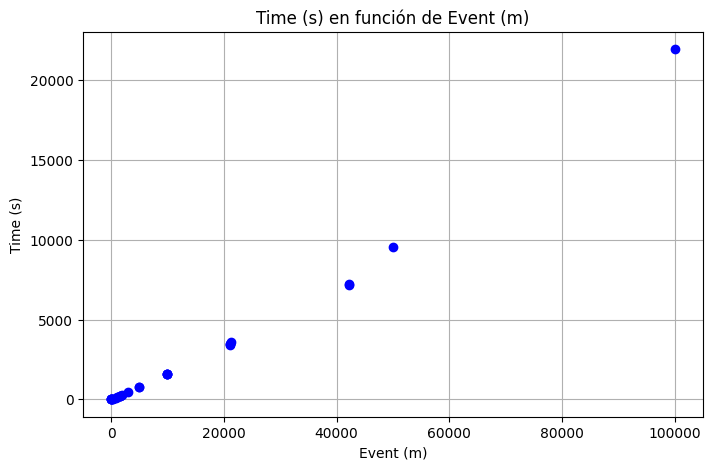

In [6]:

import matplotlib.pyplot as plt

# Graficar
plt.figure(figsize=(8,5))
plt.plot(male_df["Event (m)"], male_df["Time (s)"], marker='o', linestyle='None', color='blue')

# Etiquetas y título
plt.xlabel("Event (m)")
plt.ylabel("Time (s)")
plt.title("Time (s) en función de Event (m)")
plt.grid(True)

# Mostrar gráfico
plt.show()


## The previous plot looks linear but it is not the trend: at shorter distances runners are faster

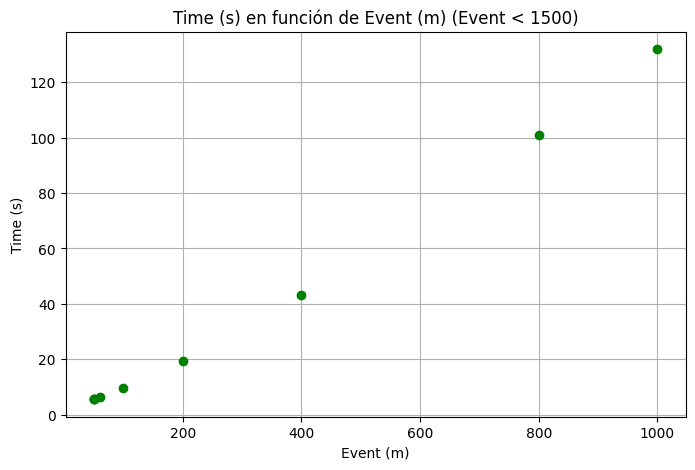

In [7]:
import matplotlib.pyplot as plt

# Filtrar los datos
df_filtrado = male_df[male_df["Event (m)"] < 1500]

# Graficar
plt.figure(figsize=(8,5))
plt.plot(df_filtrado["Event (m)"], df_filtrado["Time (s)"],
         marker='o', linestyle='None', color='green')

# Etiquetas y título
plt.xlabel("Event (m)")
plt.ylabel("Time (s)")
plt.title("Time (s) en función de Event (m) (Event < 1500)")
plt.grid(True)

# Mostrar gráfico
plt.show()


## The previous plot looks linear but it is not the trend: at shorter distances runners are faster

Then I will represent now the speed (m/s) as a function of the distance (m)

In [8]:
male_df["Speed (m/s)"] = male_df["Event (m)"] / male_df["Time (s)"]
display(male_df)

,Event (m),Time (s),Speed (m/s)
0,50.000,5.55,9.009009
1,50.000,5.56,8.992806
2,50.000,5.56,8.992806
3,60.000,6.34,9.463722
4,100.000,9.58,10.438413
5,200.000,19.19,10.422095
7,400.000,43.03,9.295840
11,800.000,100.91,7.927857
13,1000.000,131.96,7.578054
15,1500.000,206.00,7.281553


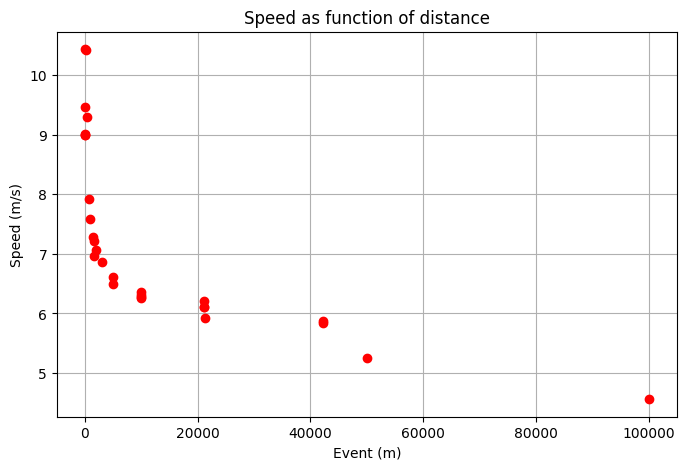

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(male_df["Event (m)"], male_df["Speed (m/s)"], marker='o', linestyle='None', color='red')

plt.xlabel("Event (m)")
plt.ylabel("Speed (m/s)")
plt.title("Speed as function of distance")
plt.grid(True)
plt.show()


# clearly the speed decreases with the distance
But till a distance (lets say 1500m) it decreases a lot, then it does not decreases that mucho. Probably it is related with aerobic and anaerobic metabolization.

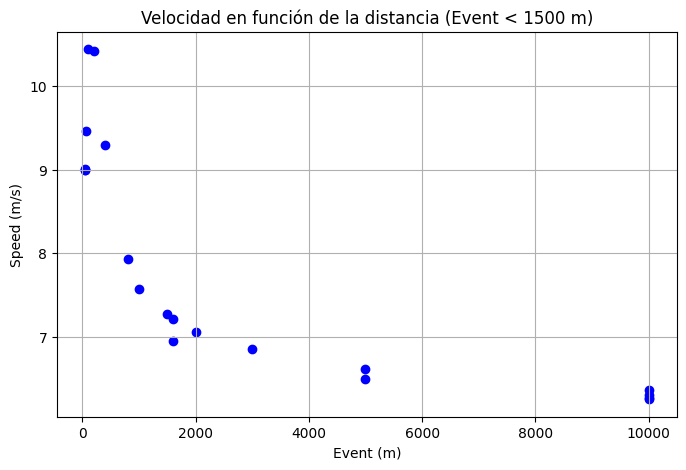

In [10]:
import matplotlib.pyplot as plt

# Filtrar hasta 5000 m
df_filtrado = male_df[male_df["Event (m)"] < 11000]

# Graficar solo puntos
plt.figure(figsize=(8,5))
plt.scatter(
    df_filtrado["Event (m)"],
    df_filtrado["Speed (m/s)"],
    color='blue'
)

plt.xlabel("Event (m)")
plt.ylabel("Speed (m/s)")
plt.title("Velocidad en función de la distancia (Event < 1500 m)")
plt.grid(True)
plt.show()


# Conclusion:
- till 100m the average speed increases when the distance increases. Probably it is due to the delay at the starting time.
- 200 m decreases a bit which respect to the 100m 
- from 200 m to 10000 m decreases a lot the average speed (seems that like a clear function). Probably there is a change in how the metabolism is used in short an mid distances.
- finally we see in the previous plot (red) that the average speed decreases again but less for long distances.